           mean       std    min  25% Quartile  50% (Median)  75% Quartile  \
Oil    1.033742  6.423115 -34.65       -2.4575         0.925        4.5200   
Banks  1.153817  7.021584 -34.71       -2.1625         1.220        4.6650   
Txtls  0.927075  7.936483 -36.02       -3.1825         1.060        5.1325   
Toys   0.919058  9.191692 -43.34       -4.3200         0.880        5.7925   
Rtail  1.060908  5.950952 -30.57       -2.0725         1.020        4.2875   

         max  kurtosis  skewness  
Oil    39.47  4.239962  0.234869  
Banks  41.79  4.695427 -0.034656  
Txtls  62.01  9.002953  0.814520  
Toys   75.27  7.094770  0.748315  
Rtail  43.52  5.522276  0.041473  


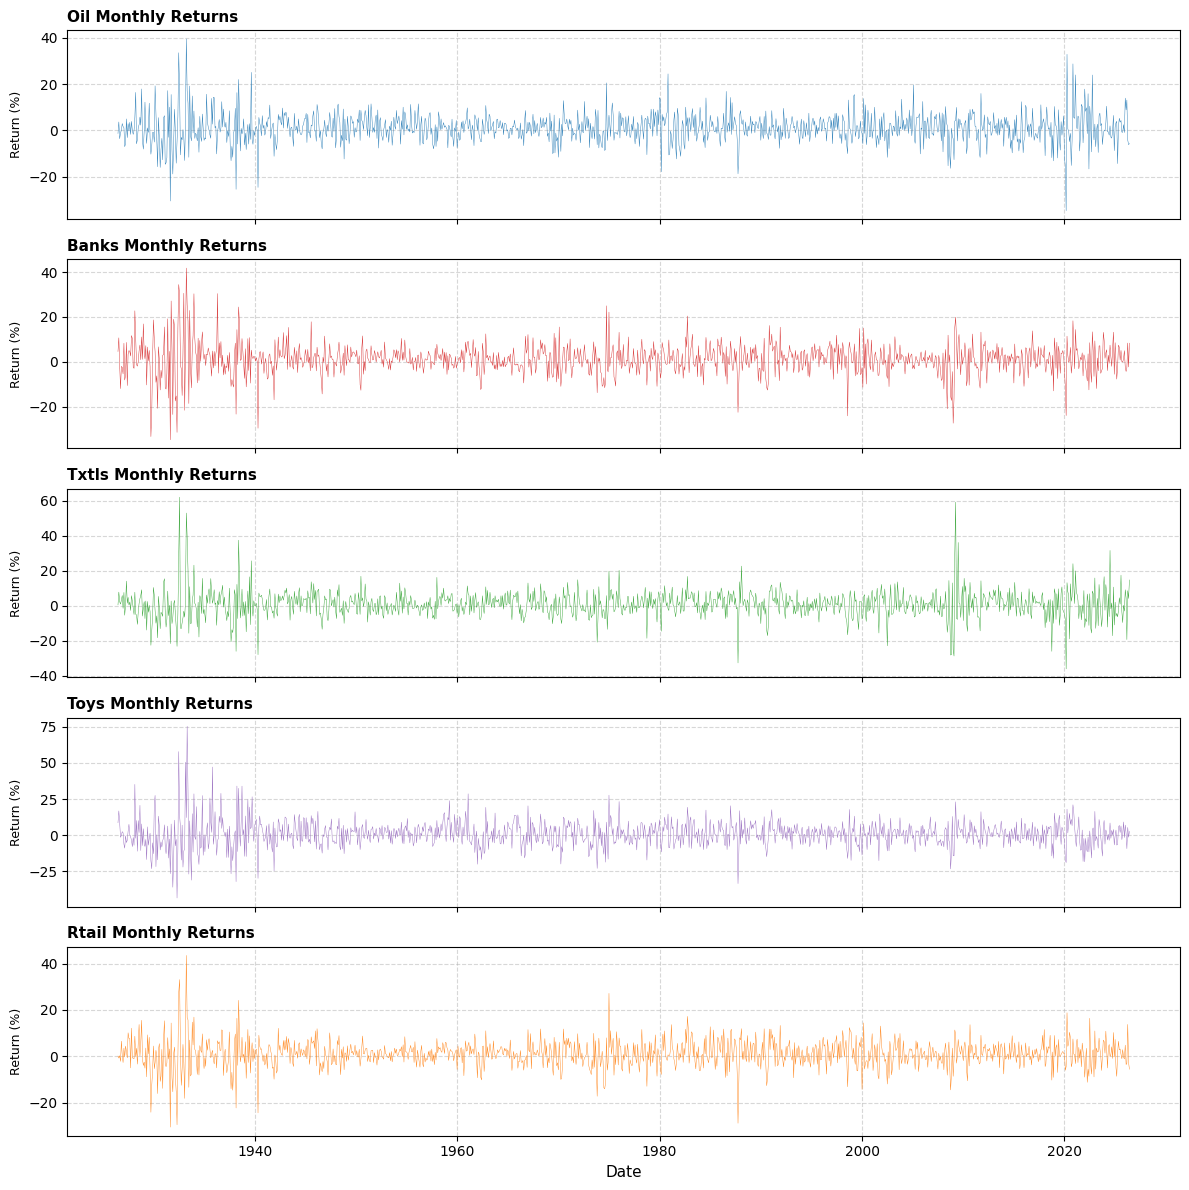

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Load the CSV
returns = pd.read_csv('49_Industry_Portfolios.csv', skiprows=11, engine='python', on_bad_lines='skip')
FF5=pd.read_csv('F-F_Research_Data_5_Factors_2x3.csv', skiprows=4, engine='python', on_bad_lines='skip')
momentum=pd.read_csv('F-F_Momentum_Factor.csv', skiprows=13, engine='python', on_bad_lines='skip')

# Rename the first column to 'Date'
returns = returns.rename(columns={returns.columns[0]: 'Date'})
FF5 = FF5.rename(columns={FF5.columns[0]: 'Date'})
momentum = momentum.rename(columns={momentum.columns[0]: 'Date'})

#Cleaning up the column strings to remove white space
returns.columns = returns.columns.str.strip()
FF5.columns = FF5.columns.str.strip()
momentum.columns = momentum.columns.str.strip()

# Choosing which industries to use
keep_cols = ['Date', 'Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

# Only keep the chosen industry returns
returns = returns[keep_cols]

# Removing the unused rows
returns = returns.iloc[:1200].reset_index(drop=True)
FF5 = FF5.iloc[:756].reset_index(drop=True)
momentum = momentum.iloc[:1195].reset_index(drop=True)

# Change data type to numeric
returns = returns.apply(pd.to_numeric, errors='coerce')
FF5 = FF5.apply(pd.to_numeric, errors='coerce')
momentum = momentum.apply(pd.to_numeric, errors='coerce')

#Join the factors together
factors = pd.merge(FF5, momentum, on='Date')

#
desc_stats = pd.DataFrame(
    {
        'mean': returns.drop(columns=['Date']).mean(),
        'std': returns.drop(columns=['Date']).std(),
        'min': returns.drop(columns=['Date']).min(),
        '25% Quartile': returns.drop(columns=['Date']).quantile(0.25),
        '50% (Median)': returns.drop(columns=['Date']).median(),
        '75% Quartile': returns.drop(columns=['Date']).quantile(0.75),
        'max': returns.drop(columns=['Date']).max(),
        'kurtosis': returns.drop(columns=['Date']).kurtosis(),
        'skewness': returns.drop(columns=['Date']).skew()
    }
)

print(desc_stats)

# Convert date to datetime strings YYYYMM
returns['Date'] = pd.to_datetime(
    returns['Date'].astype(str).str.split('.').str[0], 
    format='%Y%m', 
    errors='coerce'
)


industry_cols = ['Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]
# Create a 5x1 grid of plots sharing the same x-axis
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 12), sharex=True)

for ax, col,color in zip(axes, industry_cols,colors):
    ax.plot(returns['Date'], returns[col], linewidth=0.3, color=color)
    ax.set_title(f'{col} Monthly Returns', fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Return (%)', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

            mean       std    min  25% Quartile  50% (Median)  75% Quartile  \
Mkt-RF  0.600820  4.463052 -23.19       -1.9600         1.015        3.4300   
SMB     0.186481  3.023179 -15.54       -1.5800         0.030        1.9425   
HML     0.298413  2.968311 -13.83       -1.4325         0.215        1.7600   
RMW     0.239220  2.253332 -18.95       -0.8725         0.250        1.3100   
CMA     0.245569  2.072117  -7.08       -1.0425         0.090        1.4925   
RF      0.362923  0.260519   0.00        0.1500         0.380        0.4900   
Mom     0.621548  4.179464 -34.36       -0.9825         0.715        2.9100   

          max   kurtosis  skewness  
Mkt-RF  16.10   1.725004 -0.491924  
SMB     18.46   3.059547  0.358410  
HML     12.86   2.177249  0.090716  
RMW     13.05  10.574136 -0.380466  
CMA      9.01   1.340350  0.268441  
RF       1.35   0.832425  0.671474  
Mom     18.05   9.756146 -1.294490  


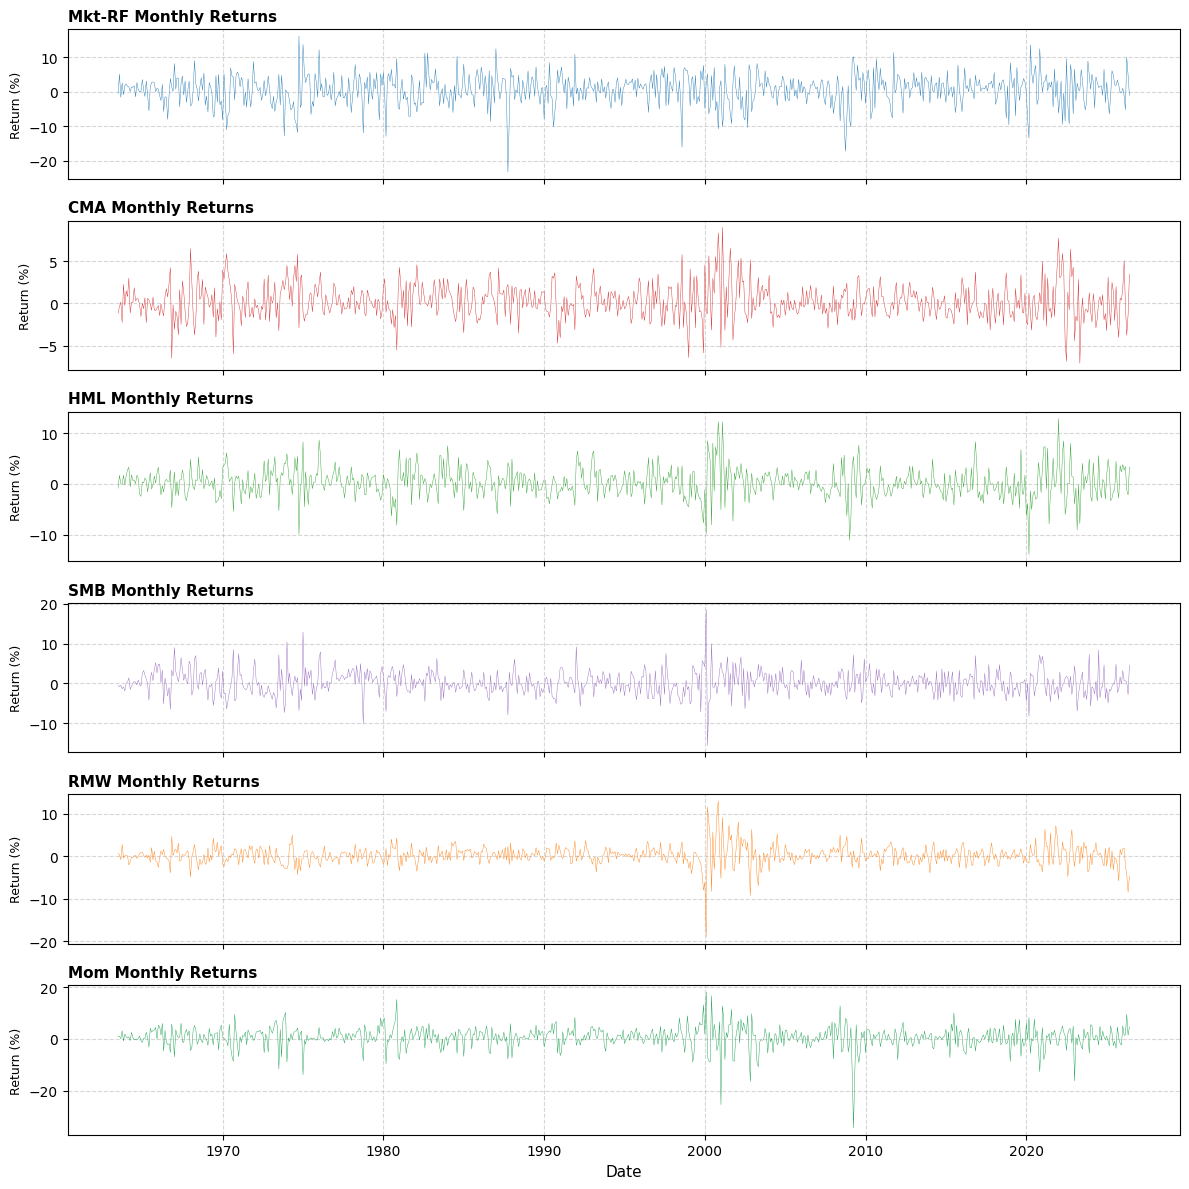

In [5]:
desc_stats_factors = pd.DataFrame(
    {
        'mean': factors.drop(columns=['Date']).mean(),
        'std': factors.drop(columns=['Date']).std(),
        'min': factors.drop(columns=['Date']).min(),
        '25% Quartile': factors.drop(columns=['Date']).quantile(0.25),
        '50% (Median)': factors.drop(columns=['Date']).median(),
        '75% Quartile': factors.drop(columns=['Date']).quantile(0.75),
        'max': factors.drop(columns=['Date']).max(),
        'kurtosis': factors.drop(columns=['Date']).kurtosis(),
        'skewness': factors.drop(columns=['Date']).skew()
    }
)

print(desc_stats_factors)

# Convert date to datetime strings YYYYMM
factors['Date'] = pd.to_datetime(
    factors['Date'].astype(str).str.split('.').str[0], 
    format='%Y%m', 
    errors='coerce'
)

factor_cols = ['Mkt-RF', 'CMA', 'HML', 'SMB', 'RMW','Mom']
colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e","#129e4a"]

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 12), sharex=True)

for ax, col,color in zip(axes, factor_cols,colors):
    ax.plot(factors['Date'], factors[col], linewidth=0.3, color=color)
    ax.set_title(f'{col} Monthly Returns', fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Return (%)', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)


plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
# Question 4a
CAPM = pd.merge(factors, returns, on='Date')

X = CAPM["Mkt-RF"]
X_with_const = sm.add_constant(X)

dependent_vars = {}
for col in ["Oil", "Banks", "Txtls", "Toys", "Rtail"]:
    dependent_vars[f"{col}"] = CAPM[col] - CAPM["RF"]

dependent_vars["Momentum"] = CAPM["Mom"]

results = []

for name, Y in dependent_vars.items():
    model = sm.OLS(Y, X_with_const).fit()

    results.append(
        {
            "Portfolio/Factor": name,
            "Mean excess returns": dependent_vars[name].mean(),
            "Alpha": model.params["const"],
            "Alpha t-stat": model.tvalues["const"],
            "Beta": model.params["Mkt-RF"],
            "Beta t-stat": model.tvalues["Mkt-RF"],
            "R-squared": model.rsquared,
        }
    )

capm_results = pd.DataFrame(results)

print(capm_results.to_string(index=False))


Portfolio/Factor  Mean excess returns     Alpha  Alpha t-stat      Beta  Beta t-stat  R-squared
             Oil             0.666164  0.164963      0.933601  0.834195    21.246707   0.374493
           Banks             0.608955 -0.037933     -0.279955  1.076674    35.761077   0.629093
           Txtls             0.570529 -0.126943     -0.618196  1.160866    25.441993   0.461926
            Toys             0.421786 -0.288841     -1.543356  1.182761    28.441590   0.517571
           Rtail             0.735992  0.134568      1.199773  1.001005    40.164571   0.681479
        Momentum             0.621548  0.714106      4.717015 -0.154053    -4.579563   0.027062


In [7]:
# Question 4b

X2 = CAPM[["Mkt-RF","SMB","HML","RMW","CMA"]]
X2_with_const = sm.add_constant(X2)

results2 = []

for name, Y in dependent_vars.items():
    model2 = sm.OLS(Y, X2_with_const).fit()

    results2.append(
        {
            "Industry portfolio": name,
            "Intercept": model2.params["const"],
            "Intercept t-stat": model2.tvalues["const"],
            "Beta Mkt-RF": model2.params["Mkt-RF"],
            "Beta Mkt-RF t-stat": model2.tvalues["Mkt-RF"],
            "Beta SMB": model2.params["SMB"],
            "Beta SMB t-stat": model2.tvalues["SMB"],
            "Beta HML": model2.params["HML"],
            "Beta HML t-stat": model2.tvalues["HML"],
            "Beta RMW": model2.params["RMW"],
            "Beta RMW t-stat": model2.tvalues["RMW"],
            "Beta CMA": model2.params["CMA"],
            "Beta CMA t-stat": model2.tvalues["CMA"],
        }
    )

capm_results2 = pd.DataFrame(results2)

print(capm_results2.to_string(index=False))

Industry portfolio  Intercept  Intercept t-stat  Beta Mkt-RF  Beta Mkt-RF t-stat  Beta SMB  Beta SMB t-stat  Beta HML  Beta HML t-stat  Beta RMW  Beta RMW t-stat  Beta CMA  Beta CMA t-stat
               Oil  -0.169329         -0.997116     0.973891           23.706046 -0.027306        -0.459286  0.383711         5.002484  0.217911         2.767811  0.361686         3.159013
             Banks  -0.242073         -2.090793     1.153467           41.181698 -0.080524        -1.986575  0.846026        16.177672  0.039311         0.732361 -0.361817        -4.635094
             Txtls  -0.615674         -3.520161     1.158736           27.386118  0.838623        13.696052  0.590698         7.477293  0.573956         7.078377  0.081648         0.692409
              Toys  -0.534673         -3.032179     1.119271           26.238330  0.708101        11.470413  0.006902         0.086659  0.556264         6.804417  0.068419         0.575505
             Rtail   0.058505          0.525907     0.9

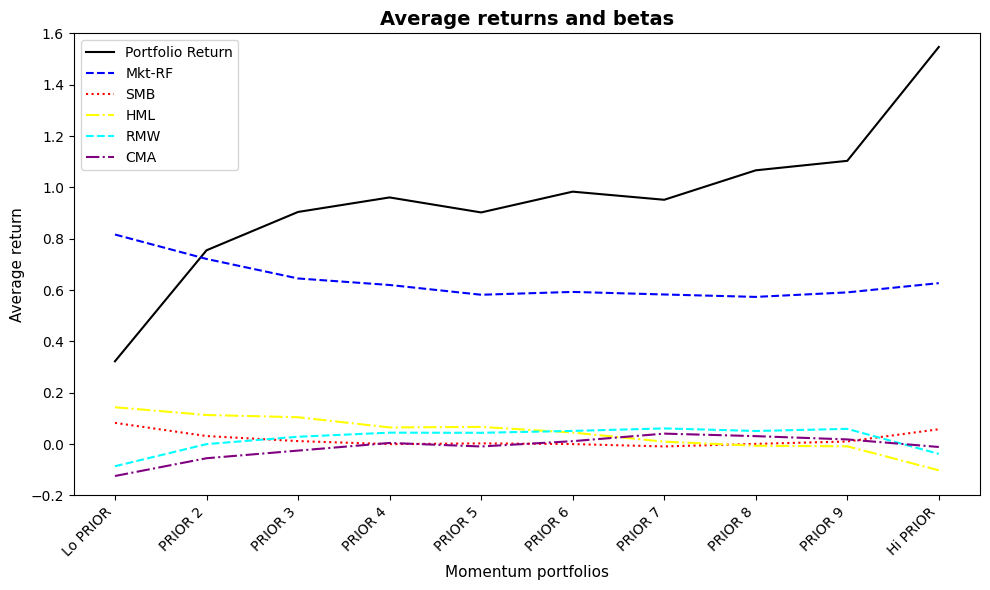

In [ ]:
# Question 4c
momentum_portfolios=pd.read_csv('10_Portfolios_Prior_12_2.csv', skiprows=10, engine='python', on_bad_lines='skip')
momentum_portfolios = momentum_portfolios.rename(columns={momentum_portfolios.columns[0]: 'Date'})
momentum_portfolios.columns = momentum_portfolios.columns.str.strip()
momentum_portfolios = momentum_portfolios.iloc[:1195].reset_index(drop=True)
momentum_portfolios = momentum_portfolios.apply(pd.to_numeric, errors='coerce')
momentum_portfolios['Date'] = pd.to_datetime(
    momentum_portfolios['Date'].astype(str).str.split('.').str[0], 
    format='%Y%m', 
    errors='coerce'
)
X3= CAPM[["Mkt-RF","SMB","HML","RMW","CMA"]]
X3_const = sm.add_constant(X3)
momentum_portfolios = momentum_portfolios[momentum_portfolios['Date'].isin(CAPM['Date'])].reset_index(drop=True)

factor_mean=X3.mean()
dependent_vars2 = {}
for col in momentum_portfolios.columns[1:]:
    dependent_vars2[f"{col}"] = momentum_portfolios[col] - CAPM["RF"]

results3=[]
for name, Y in dependent_vars2.items():
    model3 = sm.OLS(Y, X3_const).fit()

    results3.append(
        {
            "Momentum portfolio": name,
            "Beta Mkt-RF": model3.params["Mkt-RF"],
            "Beta SMB": model3.params["SMB"],
            "Beta HML": model3.params["HML"],
            "Beta RMW": model3.params["RMW"],
            "Beta CMA": model3.params["CMA"],
        }
    )
factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

factor_effects = {f: [] for f in factor_cols}
for row in results3:
    factor_effects["Mkt-RF"].append(row["Beta Mkt-RF"] * factor_mean["Mkt-RF"])
    factor_effects["SMB"].append(row["Beta SMB"] * factor_mean["SMB"])
    factor_effects["HML"].append(row["Beta HML"] * factor_mean["HML"])
    factor_effects["RMW"].append(row["Beta RMW"] * factor_mean["RMW"])
    factor_effects["CMA"].append(row["Beta CMA"] * factor_mean["CMA"])

portfolio_names = list(momentum_portfolios.columns[1:])
avg_returns = [momentum_portfolios[col].mean() for col in portfolio_names]
x_axis = np.arange(len(portfolio_names))
styles = {
    'Mkt-RF': ('blue', '--'),
    'SMB': ('red', ':'),
    'HML': ('yellow', '-.'),
    'RMW': ('green', '--'),
    'CMA': ('purple', '-.')
}
plt.figure(figsize=(10, 6))

# Plot Portfolio Average Excess Returns
plt.plot(x_axis, avg_returns, color='black', label='Portfolio Return', linewidth=1.5)

# Plot each Factor Effect Line
for f in factor_cols:
    color, lstyle = styles[f]
    plt.plot(x_axis, factor_effects[f], label=f, color=color, linestyle=lstyle)

plt.title('Average returns and betas', fontsize=14, fontweight='bold')
plt.xlabel('Momentum portfolios', fontsize=11)
plt.ylabel('Average return', fontsize=11)
plt.xticks(ticks=x_axis, labels=portfolio_names, rotation=45, ha='right')
plt.ylim(-0.2, 1.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()